# 1️⃣ - Evaluation des modèles sur VAL pendant tout le processus, et sortir les résultats finaux sur TEST

In [23]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import numpy as np
import json
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import shutil
import tensorflow as tf
import seaborn as sns

In [ ]:

IMAGES_PATH = "/Volumes/T9/HAM10000"
CSV_PATH = "/Volumes/T9/HAM10000_metadata.csv"
df = pd.read_csv("/Volumes/T9/HAM10000_metadata.csv")
# Définition des classes à conserver
# --- Labels ---
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

In [7]:

# 📁 Mapping des chemins images dans une nouvelle colonne 'path'
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))

# 🏷️ Label to index mapping
label_to_index = {v: k for k, v in CLASS_LABELS.items()}
df = df[df['dx'].isin(CLASS_LABELS.values())]
df['label'] = df['dx'].map(label_to_index)


In [8]:


# === 0. Paramètres ===
DATASET_DIR = '/Volumes/T9/HAM10000'  # répertoire contenant toutes les images originales
SAVE_DIR = '/Volumes/T9/HAM10000/data_split'  # répertoire cible pour sauvegarde
os.makedirs(SAVE_DIR, exist_ok=True)

# === 1. Split en 70% train, 15% val, 15% test ===
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

# Conversion des labels en str (requis pour Keras et ImageDataGenerator)
for subset in [train_df, val_df, test_df]:
    subset['label'] = subset['label'].astype(str)



In [10]:


# --- Mappings utiles ---
label_to_index = {v: k for k, v in CLASS_LABELS.items()}
index_to_label = {k: v for k, v in CLASS_LABELS.items()}
ordered_names = [CLASS_LABELS[i] for i in range(len(CLASS_LABELS))]

# Xception - Sur VAL

32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 268ms/step


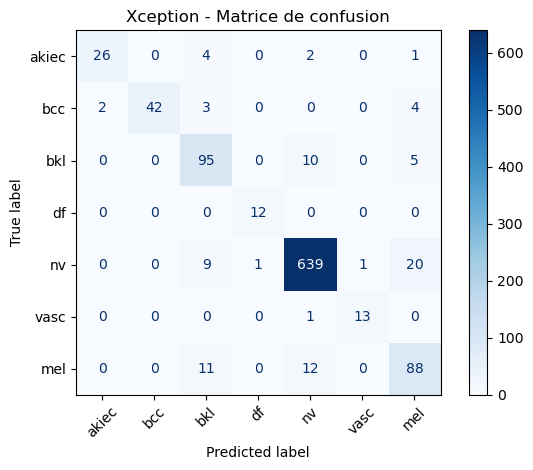

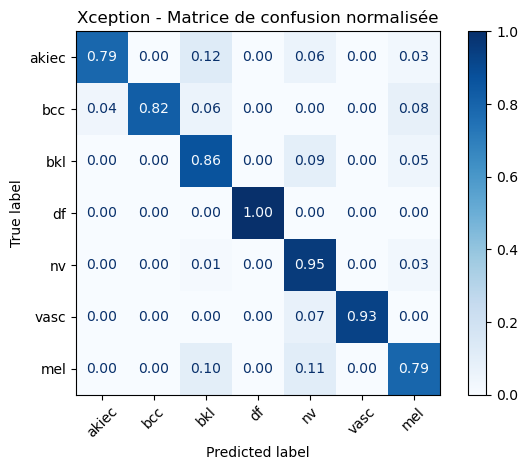

Rapport de classification :
              precision    recall  f1-score   support

       akiec       0.93      0.79      0.85        33
         bcc       1.00      0.82      0.90        51
         bkl       0.78      0.86      0.82       110
          df       0.92      1.00      0.96        12
          nv       0.96      0.95      0.96       670
        vasc       0.93      0.93      0.93        14
         mel       0.75      0.79      0.77       111

    accuracy                           0.91      1001
   macro avg       0.90      0.88      0.88      1001
weighted avg       0.92      0.91      0.92      1001



In [12]:


from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input


# 📐 IMAGE et PREPROCESS

IMG_SIZE = (299, 299)


# 1) NE PAS forcer en str — au contraire, on normalise proprement plus bas
# test_df['label'] = test_df['label'].astype(str)  # ⛔️ on enlève

# 2) Charger le modèle
model = load_model('Protocole-S-V2-Xception-phaseAvecTAG4-valAUC.keras', compile=False)

# 3) Prétraitement image
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 4) Normalisation robuste des labels → indices [0..6]
def to_index_array(labels):
    indices = []
    for l in labels:
        if pd.isna(l):
            raise ValueError("Label manquant (NaN) détecté.")
        # déjà int
        if isinstance(l, (int, np.integer)):
            indices.append(int(l))
            continue
        s = str(l)
        # chaîne d’index ('0'..'6')
        if s.isdigit():
            indices.append(int(s))
            continue
        # nom de classe ('mel', 'akiec', ...)
        if s in label_to_index:
            indices.append(label_to_index[s])
            continue
        raise KeyError(f"Label inconnu: {s} (attendus: {ordered_names} ou indices 0..6)")
    return np.array(indices, dtype=int)

# 5) Préparer les données
X_val = preprocess_images(val_df['path'])
y_true_raw = val_df['label'].values
y_true_encoded = to_index_array(y_true_raw)

# 6) Prédictions
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# 7) Matrice de confusion (brute)
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ordered_names)
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Xception - Matrice de confusion")
plt.tight_layout()
plt.show()

# (Optionnel) Matrice normalisée par ligne (%)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=ordered_names)
disp_norm.plot(xticks_rotation=45, cmap="Blues", values_format=".2f")
plt.title("Xception - Matrice de confusion normalisée")
plt.tight_layout()
plt.show()

# 8) Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=ordered_names))


# INCEPTION V3 - sur VAL

32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 195ms/step


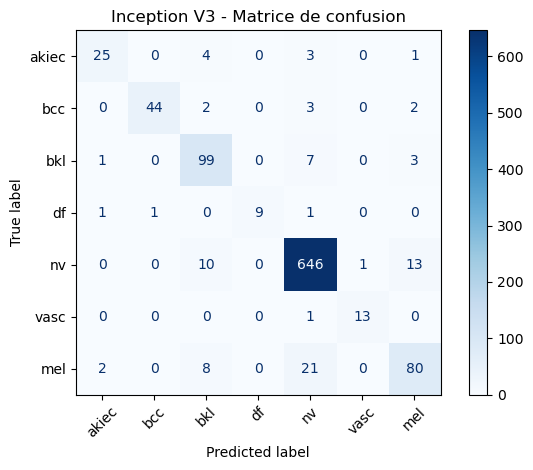

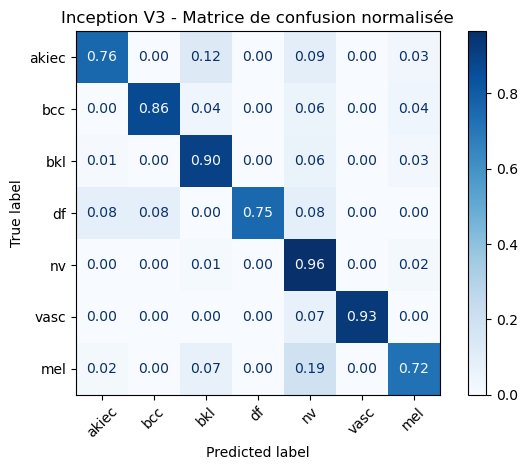

Rapport de classification :
              precision    recall  f1-score   support

       akiec       0.86      0.76      0.81        33
         bcc       0.98      0.86      0.92        51
         bkl       0.80      0.90      0.85       110
          df       1.00      0.75      0.86        12
          nv       0.95      0.96      0.96       670
        vasc       0.93      0.93      0.93        14
         mel       0.81      0.72      0.76       111

    accuracy                           0.92      1001
   macro avg       0.90      0.84      0.87      1001
weighted avg       0.92      0.92      0.91      1001



In [17]:

# 📐 IMAGE et PREPROCESS
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
IMG_SIZE = (299, 299)


# 2) Charger le modèle
model = load_model('/Volumes/T9/Protocole-S-Best/Protocole-S-InceptionV3.keras', compile=False)


# 3) Prétraitement image
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 4) Normalisation robuste des labels → indices [0..6]
def to_index_array(labels):
    indices = []
    for l in labels:
        if pd.isna(l):
            raise ValueError("Label manquant (NaN) détecté.")
        # déjà int
        if isinstance(l, (int, np.integer)):
            indices.append(int(l))
            continue
        s = str(l)
        # chaîne d’index ('0'..'6')
        if s.isdigit():
            indices.append(int(s))
            continue
        # nom de classe ('mel', 'akiec', ...)
        if s in label_to_index:
            indices.append(label_to_index[s])
            continue
        raise KeyError(f"Label inconnu: {s} (attendus: {ordered_names} ou indices 0..6)")
    return np.array(indices, dtype=int)

# 5) Préparer les données
X_val = preprocess_images(val_df['path'])
y_true_raw = val_df['label'].values
y_true_encoded = to_index_array(y_true_raw)

# 6) Prédictions
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# 7) Matrice de confusion (brute)
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ordered_names)
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Inception V3 - Matrice de confusion")
plt.tight_layout()
plt.show()

# (Optionnel) Matrice normalisée par ligne (%)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=ordered_names)
disp_norm.plot(xticks_rotation=45, cmap="Blues", values_format=".2f")
plt.title("Inception V3 - Matrice de confusion normalisée")
plt.tight_layout()
plt.show()

# 8) Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=ordered_names))


# RESNET 50 sur VAL

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 165ms/step


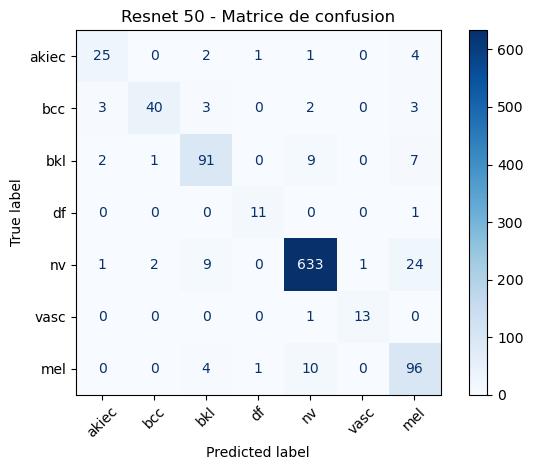

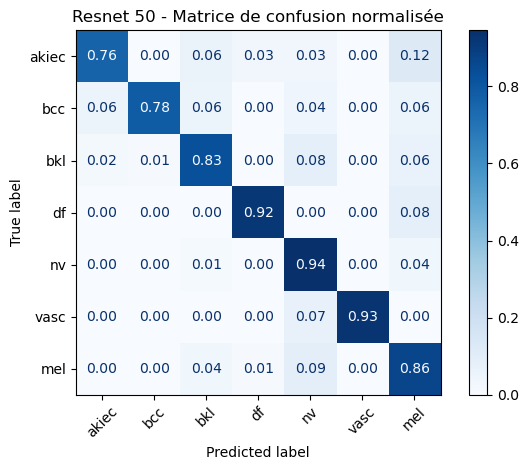

Rapport de classification :
              precision    recall  f1-score   support

       akiec       0.81      0.76      0.78        33
         bcc       0.93      0.78      0.85        51
         bkl       0.83      0.83      0.83       110
          df       0.85      0.92      0.88        12
          nv       0.96      0.94      0.95       670
        vasc       0.93      0.93      0.93        14
         mel       0.71      0.86      0.78       111

    accuracy                           0.91      1001
   macro avg       0.86      0.86      0.86      1001
weighted avg       0.91      0.91      0.91      1001



In [21]:


# 📐 IMAGE et PREPROCESS
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
IMG_SIZE = (224, 224)


# 2) Charger le modèle
model = load_model('/Volumes/T9/Protocole-S-Best/Protocole-S-Resnet50.keras', compile=False)

# 3) Prétraitement image
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_resnet(img_array)
    return img_array

def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 4) Normalisation robuste des labels → indices [0..6]
def to_index_array(labels):
    indices = []
    for l in labels:
        if pd.isna(l):
            raise ValueError("Label manquant (NaN) détecté.")
        # déjà int
        if isinstance(l, (int, np.integer)):
            indices.append(int(l))
            continue
        s = str(l)
        # chaîne d’index ('0'..'6')
        if s.isdigit():
            indices.append(int(s))
            continue
        # nom de classe ('mel', 'akiec', ...)
        if s in label_to_index:
            indices.append(label_to_index[s])
            continue
        raise KeyError(f"Label inconnu: {s} (attendus: {ordered_names} ou indices 0..6)")
    return np.array(indices, dtype=int)

# 5) Préparer les données
X_val = preprocess_images(val_df['path'])
y_true_raw = val_df['label'].values
y_true_encoded = to_index_array(y_true_raw)

# 6) Prédictions
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# 7) Matrice de confusion (brute)
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ordered_names)
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Resnet 50 - Matrice de confusion")
plt.tight_layout()
plt.show()

# (Optionnel) Matrice normalisée par ligne (%)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=ordered_names)
disp_norm.plot(xticks_rotation=45, cmap="Blues", values_format=".2f")
plt.title("Resnet 50 - Matrice de confusion normalisée")
plt.tight_layout()
plt.show()

# 8) Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=ordered_names))


32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 440ms/step


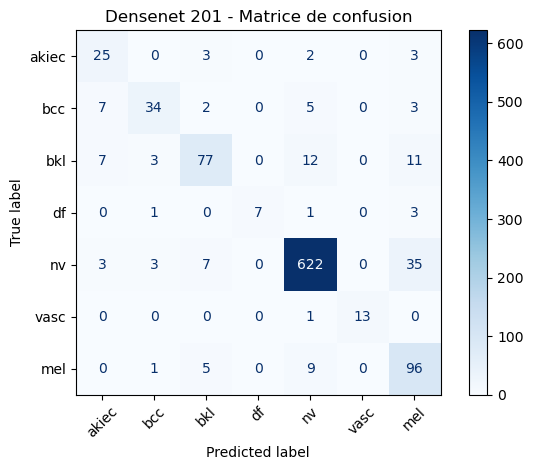

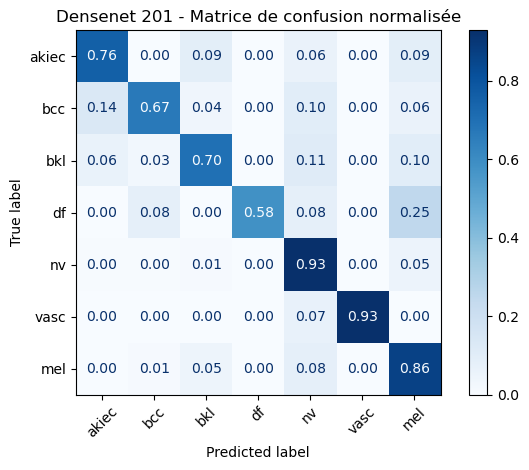

Rapport de classification :
              precision    recall  f1-score   support

       akiec       0.60      0.76      0.67        33
         bcc       0.81      0.67      0.73        51
         bkl       0.82      0.70      0.75       110
          df       1.00      0.58      0.74        12
          nv       0.95      0.93      0.94       670
        vasc       1.00      0.93      0.96        14
         mel       0.64      0.86      0.73       111

    accuracy                           0.87      1001
   macro avg       0.83      0.78      0.79      1001
weighted avg       0.89      0.87      0.88      1001



In [22]:

# 📐 IMAGE et PREPROCESS
from tensorflow.keras.applications.densenet import preprocess_input
IMG_SIZE = (224, 224)

# 2) Charger le modèle
model = load_model('Protocole-S-V2-Densenet201-Phase8-11-valAUC.keras', compile=False)

# 3) Prétraitement image
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 4) Normalisation robuste des labels → indices [0..6]
def to_index_array(labels):
    indices = []
    for l in labels:
        if pd.isna(l):
            raise ValueError("Label manquant (NaN) détecté.")
        # déjà int
        if isinstance(l, (int, np.integer)):
            indices.append(int(l))
            continue
        s = str(l)
        # chaîne d’index ('0'..'6')
        if s.isdigit():
            indices.append(int(s))
            continue
        # nom de classe ('mel', 'akiec', ...)
        if s in label_to_index:
            indices.append(label_to_index[s])
            continue
        raise KeyError(f"Label inconnu: {s} (attendus: {ordered_names} ou indices 0..6)")
    return np.array(indices, dtype=int)

# 5) Préparer les données
X_val = preprocess_images(val_df['path'])
y_true_raw = val_df['label'].values
y_true_encoded = to_index_array(y_true_raw)

# 6) Prédictions
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# 7) Matrice de confusion (brute)
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ordered_names)
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Densenet 201 - Matrice de confusion")
plt.tight_layout()
plt.show()

# (Optionnel) Matrice normalisée par ligne (%)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=ordered_names)
disp_norm.plot(xticks_rotation=45, cmap="Blues", values_format=".2f")
plt.title("Densenet 201 - Matrice de confusion normalisée")
plt.tight_layout()
plt.show()

# 8) Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=ordered_names))


# 2️⃣ - GRID SEARCH avec CROSS VALIDATION

Prédictions modèles:   0%|          | 0/32 [00:00<?, ?it/s]

Prédictions modèles: 100%|██████████| 32/32 [00:58<00:00,  1.82s/it]



🔎 Top 10 combinaisons (triées par recall CV) :
 Xception  ResNet  DenseNet  avg_recall_cv  avg_recall  avg_specificity  avg_auc
   0.5000  0.2500    0.2500         0.8639      0.8855           0.9809   0.9761
   0.7500  0.0000    0.2500         0.8618      0.8833           0.9807   0.9908
   0.7500  0.2500    0.0000         0.8556      0.8790           0.9802   0.9655
   1.0000  0.0000    0.0000         0.8556      0.8790           0.9805   0.9881
   0.5000  0.0000    0.5000         0.8548      0.8716           0.9798   0.9901
   0.5000  0.5000    0.0000         0.8500      0.8744           0.9787   0.9625
   0.2500  0.2500    0.5000         0.7836      0.8080           0.9753   0.9750
   0.2500  0.0000    0.7500         0.7765      0.7996           0.9740   0.9885
   0.0000  0.0000    1.0000         0.7590      0.7756           0.9718   0.9788
   0.2500  0.5000    0.2500         0.7563      0.7768           0.9710   0.9728

✅ Meilleurs poids trouvés (CV) : Xception=0.50, ResNet=0.25,

Prédictions modèles: 100%|██████████| 32/32 [00:30<00:00,  1.05it/s]

              precision    recall  f1-score   support

       akiec       0.90      0.79      0.84        33
         bcc       1.00      0.82      0.90        51
         bkl       0.82      0.86      0.84       110
          df       0.92      1.00      0.96        12
          nv       0.96      0.96      0.96       670
        vasc       0.87      0.93      0.90        14
         mel       0.77      0.84      0.80       111

    accuracy                           0.92      1001
   macro avg       0.89      0.89      0.89      1001
weighted avg       0.92      0.92      0.92      1001



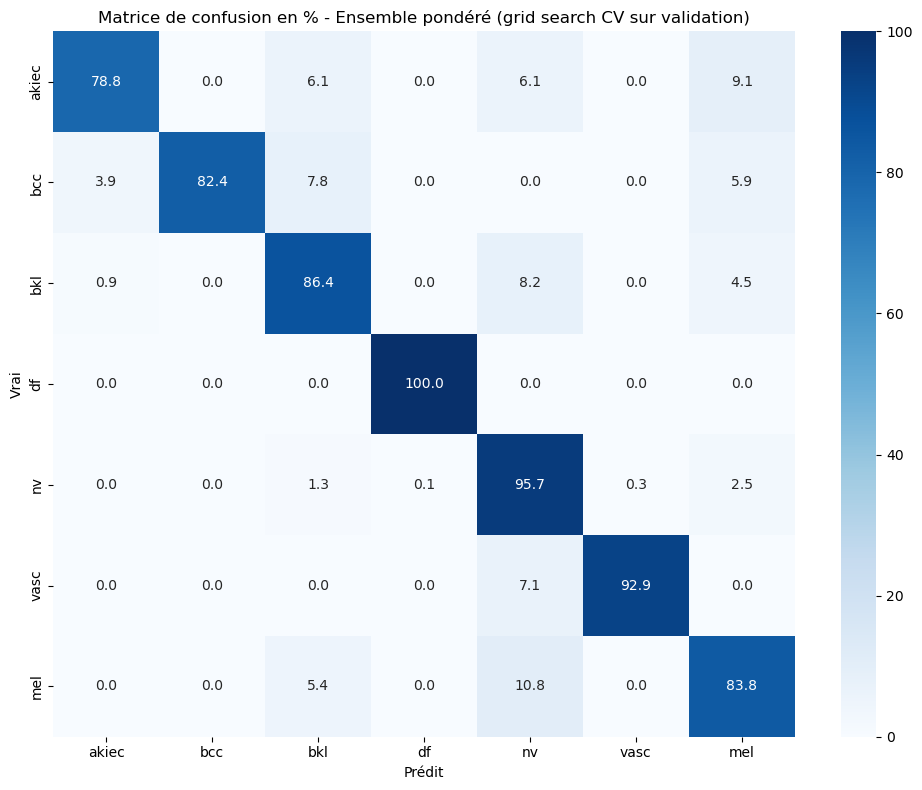

In [24]:

from sklearn.metrics import confusion_matrix, classification_report, recall_score, roc_auc_score
from sklearn.model_selection import KFold
from tqdm import tqdm
import itertools
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet

# ---- Configuration ----
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']
N_CLASSES = len(CLASS_NAMES)
label_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}

# =======================
# Chargement des données
# =======================
val_df = val_df[val_df['dx'].isin(CLASS_NAMES)].copy()
val_df['path'] = val_df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))
val_df['label'] = val_df['dx'].map(label_to_index)

# ---- Chargement des modèles ----
model_xcept_big = load_model("Protocole-S-V2-Xception-phaseSansTAG-valACC.keras", compile=False)
model_resnet50  = load_model("/Volumes/T9/Protocole-S-Best/Protocole-S-Resnet50.keras", compile=False)
model_densenet201 = load_model("Protocole-S-V2-Densenet201-Phase8-11-valAUC.keras",
                               compile=False,
                               custom_objects={'preprocess_input': preprocess_densenet})

# ---- Préparation des images ----
def load_image_paths(paths, target_size):
    return np.array([
        image.img_to_array(image.load_img(p, target_size=target_size, color_mode="rgb"))
        for p in paths
    ])

# ---- Prédiction en batch ----
def predict_models(image_paths, batch_size=32):
    preds_xcept, preds_resnet, preds_densenet = [], [], []
    num_images = len(image_paths)
    for i in tqdm(range(0, num_images, batch_size), desc="Prédictions modèles"):
        batch_paths = image_paths[i:i + batch_size]
        batch_xcept      = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        batch_resnet     = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))
        batch_densenet   = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))
        preds_xcept.append(model_xcept_big.predict(batch_xcept, verbose=0))
        preds_resnet.append(model_resnet50.predict(batch_resnet, verbose=0))
        preds_densenet.append(model_densenet201.predict(batch_densenet, verbose=0))
    return np.vstack(preds_xcept), np.vstack(preds_resnet), np.vstack(preds_densenet)

# ---- Calcul des métriques ----
def compute_metrics(y_true, y_pred, y_proba, class_names=CLASS_NAMES):
    n_classes = len(class_names)

    # Recall (sensibilité)
    recalls = recall_score(y_true, y_pred, average=None, labels=np.arange(n_classes))
    avg_recall = recalls.mean()

    # Specificity (par confusion matrix)
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))
    specificities = []
    for i in range(n_classes):
        TN = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        FP = cm[:, i].sum() - cm[i, i]
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        specificities.append(specificity)
    avg_specificity = np.mean(specificities)

    # AUC
    y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=n_classes)
    avg_auc = roc_auc_score(y_true_onehot, y_proba, average="macro", multi_class="ovr")

    return {
        "avg_recall": avg_recall,
        "avg_specificity": avg_specificity,
        "avg_auc": avg_auc,
        "recalls_per_class": dict(zip(class_names, recalls)),
        "specificity_per_class": dict(zip(class_names, specificities))
    }

# ---- Évaluation pour un triplet de poids ----
def evaluate_ensemble(y_true, preds, weights):
    pred_xcept, pred_resnet, pred_densenet = preds
    y_proba = (
        pred_xcept * weights[0] +
        pred_resnet * weights[1] +
        pred_densenet * weights[2]
    )
    y_pred = np.argmax(y_proba, axis=1)

    metrics = compute_metrics(y_true, y_pred, y_proba, CLASS_NAMES)

    # 🔑 La métrique d’optimisation principale = avg_recall
    return metrics["avg_recall"], metrics

# ---- Grid search avec Cross-Validation ----
def grid_search_weights_cv(val_df, step=0.25, n_splits=5):
    y_true = val_df['label'].values
    preds = predict_models(val_df['path'].tolist())
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    search_space = np.arange(0, 1.01, step)
    results = []

    for w in itertools.product(search_space, repeat=3):
        if abs(sum(w) - 1.0) > 1e-6:
            continue

        fold_scores = []
        for train_idx, val_idx in kf.split(val_df):
            y_true_fold = y_true[val_idx]
            preds_fold = [p[val_idx] for p in preds]
            score, _ = evaluate_ensemble(y_true_fold, preds_fold, w)
            fold_scores.append(score)

        avg_score = np.mean(fold_scores)
        # Pour obtenir les autres métriques, on recalcule sur tout val_df
        _, metrics = evaluate_ensemble(y_true, preds, w)

        results.append({
            "Xception": w[0], "ResNet": w[1], "DenseNet": w[2],
            "avg_recall_cv": avg_score,
            "avg_recall": metrics["avg_recall"],
            "avg_specificity": metrics["avg_specificity"],
            "avg_auc": metrics["avg_auc"]
        })

    df_results = pd.DataFrame(results).sort_values(by="avg_recall_cv", ascending=False)

    best_row = df_results.iloc[0]
    print("\n🔎 Top 10 combinaisons (triées par recall CV) :")
    print(df_results.head(10).to_string(index=False, float_format="%.4f"))

    print(f"\n✅ Meilleurs poids trouvés (CV) : Xception={best_row['Xception']:.2f}, "
          f"ResNet={best_row['ResNet']:.2f}, DenseNet={best_row['DenseNet']:.2f}")
    print(f"→ Avg Recall (CV)={best_row['avg_recall_cv']:.4f}, "
          f"Avg Recall={best_row['avg_recall']:.4f}, "
          f"Avg Specificity={best_row['avg_specificity']:.4f}, "
          f"Avg AUC={best_row['avg_auc']:.4f}")

    return best_row[["Xception","ResNet","DenseNet"]].values, df_results

# ---- Lancement grid search avec CV ----
best_weights, df_results = grid_search_weights_cv(val_df, step=0.25, n_splits=5)

# ---- Évaluation finale avec ces poids ----
print("\n📊 Rapport de classification (validation set avec meilleurs poids)...")
y_true = val_df['label'].values
preds = predict_models(val_df['path'].tolist())
pred_final = (
    preds[0] * best_weights[0] +
    preds[1] * best_weights[1] +
    preds[2] * best_weights[2]
)
y_pred = np.argmax(pred_final, axis=1)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ---- Matrice de confusion ----
conf_matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion en % - Ensemble pondéré (grid search CV sur validation)')
plt.tight_layout()
plt.show()


# 3️⃣ Application finale sur TEST et Métriques


Évaluation de l'ensemble pondéré (Xception + ResNet50 + DenseNet201)...


Prédiction par batchs: 100%|██████████| 32/32 [01:09<00:00,  2.18s/it]


Classification Report:
              precision    recall  f1-score   support

       akiec       0.96      0.78      0.86        32
         bcc       0.98      0.92      0.95        52
         bkl       0.83      0.87      0.85       110
          df       0.91      0.91      0.91        11
          nv       0.97      0.96      0.97       671
        vasc       1.00      0.93      0.96        14
         mel       0.77      0.84      0.80       112

    accuracy                           0.93      1002
   macro avg       0.92      0.89      0.90      1002
weighted avg       0.93      0.93      0.93      1002



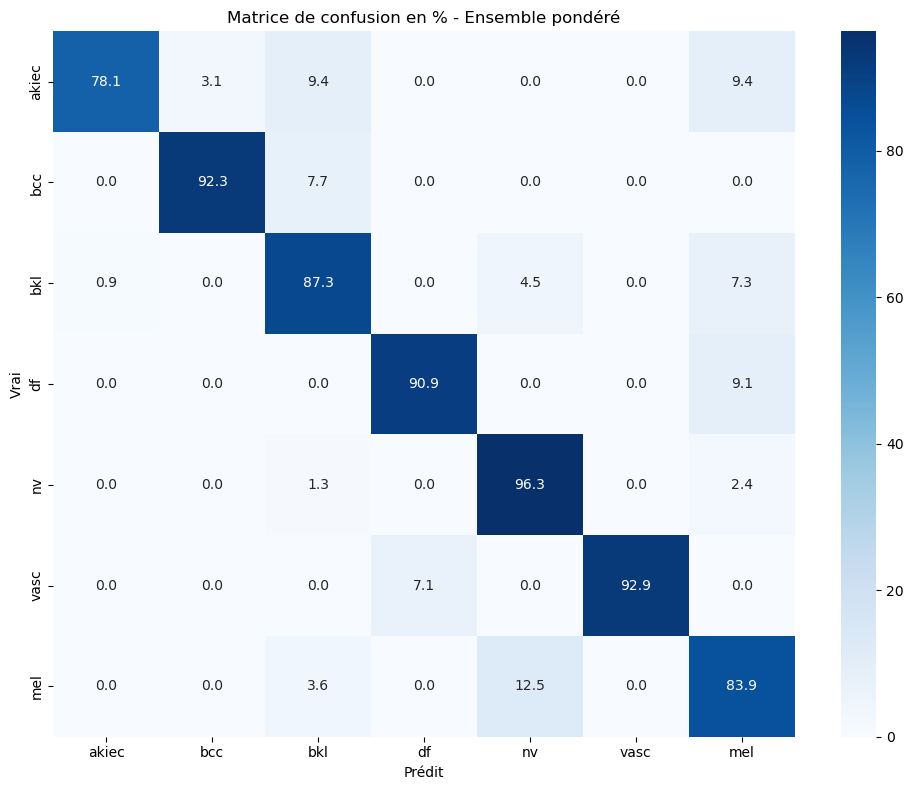

In [25]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet

# ---- Configuration ----
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']
label_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}

# ---- DataFrame df supposé dispo ----
df = df[df['dx'].isin(CLASS_NAMES)]
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))
df['label'] = df['dx'].map(label_to_index)

# Split train/val/test
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# ---- Chargement des modèles ----
model_xcept    = load_model("Protocole-S-V2-Xception-phaseSansTAG-valACC.keras", compile=False)
model_resnet50 = load_model("/Volumes/T9/Protocole-S-Best/Protocole-S-Resnet50.keras", compile=False)
model_densenet = load_model("Protocole-S-V2-Densenet201-Phase8-11-valAUC.keras", compile=False)

# ---- Préparation images ----
def load_image_paths(paths, target_size):
    return np.array([
        image.img_to_array(
            image.load_img(p, target_size=target_size, color_mode="rgb")
        ) for p in paths
    ])

# ---- Prédiction en batch avec priorisation DenseNet201 sur mel ----

#weights=(0.45, 0.25, 0.30)
def predict_ensemble(image_paths, batch_size=32, weights=(0.50, 0.25, 0.25)):
    """
    weights = (w_xception, w_resnet50, w_densenet201)
    """
    num_images = len(image_paths)
    all_predictions = []

    for i in tqdm(range(0, num_images, batch_size), desc="Prédiction par batchs"):
        batch_paths = image_paths[i:i + batch_size]

        # Chargement images adaptées
        bx = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        br = preprocess_resnet(load_image_paths(batch_paths, (224, 224)))
        bd = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))

        # Prédictions
        pred_x = model_xcept.predict(bx, verbose=0)
        pred_r = model_resnet50.predict(br, verbose=0)
        pred_d = model_densenet.predict(bd, verbose=0)

        # Moyenne pondérée
        preds = (weights[0] * pred_x +
                 weights[1] * pred_r +
                 weights[2] * pred_d)

        # --- ASTUCE : privilégier DenseNet201 pour 'mel' (classe index 6) ---
        mel_idx = label_to_index['mel']
        preds[:, mel_idx] = (0.5 * preds[:, mel_idx] + 0.5 * pred_d[:, mel_idx])

        all_predictions.extend(np.argmax(preds, axis=1))

    return np.array(all_predictions)

# ---- Évaluation ----
print("\nÉvaluation de l'ensemble pondéré (Xception + ResNet50 + DenseNet201)...")

y_true = test_df['label'].values
y_pred = predict_ensemble(test_df['path'].tolist())

print("\nClassification Report:")
print(classification_report(y_true, y_pred,
                            target_names=CLASS_NAMES,
                            labels=np.arange(len(CLASS_NAMES))))

# ---- Matrice de confusion en % ----
conf_matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion en % - Ensemble pondéré')
plt.tight_layout()
plt.show()


## TEST avec Average Specificity et Average AUC


Évaluation de l'ensemble pondéré (Xception + ResNet50 + DenseNet201)...


Prédiction par batchs:   0%|          | 0/32 [00:00<?, ?it/s]

Prédiction par batchs: 100%|██████████| 32/32 [01:22<00:00,  2.59s/it]


Classification Report:
              precision    recall  f1-score   support

       akiec       0.96      0.78      0.86        32
         bcc       0.98      0.92      0.95        52
         bkl       0.83      0.87      0.85       110
          df       0.91      0.91      0.91        11
          nv       0.97      0.96      0.97       671
        vasc       1.00      0.93      0.96        14
         mel       0.77      0.84      0.80       112

    accuracy                           0.93      1002
   macro avg       0.92      0.89      0.90      1002
weighted avg       0.93      0.93      0.93      1002



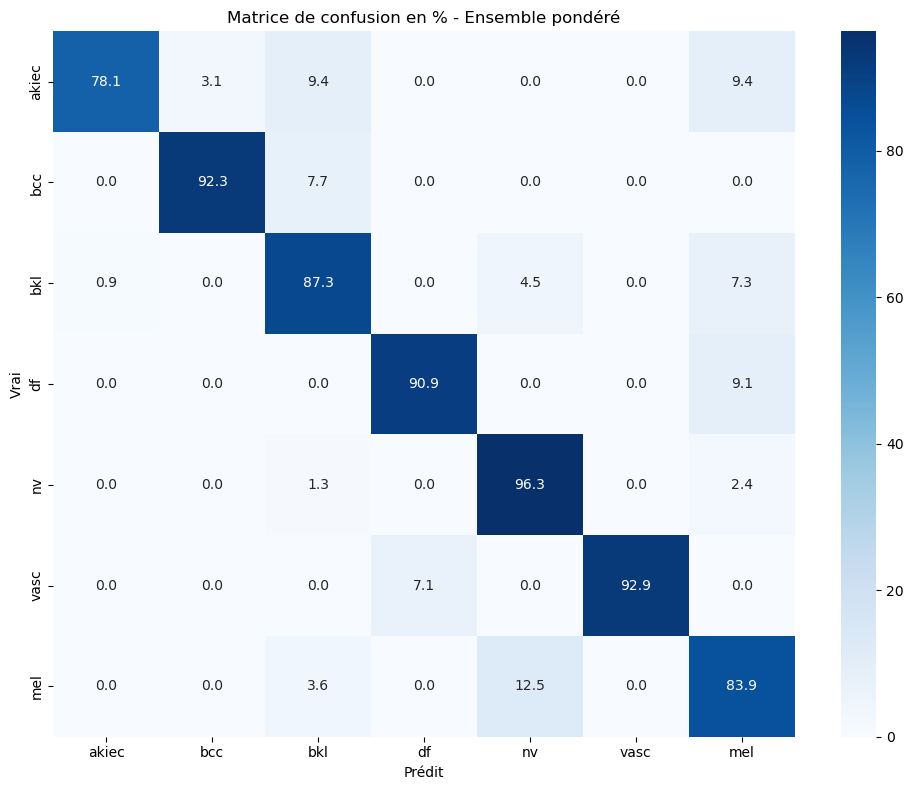


Average AUC: 0.9901
AUC par classe:
akiec: 0.9909
bcc: 0.9975
bkl: 0.9811
df: 0.9999
nv: 0.9879
vasc: 1.0000
mel: 0.9735

Average Specificity: 0.9827
Specificity par classe:
akiec: 0.9989
bcc: 0.9989
bkl: 0.9766
df: 0.9989
nv: 0.9377
vasc: 1.0000
mel: 0.9677


In [ ]:

import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_fscore_support
)
from tqdm import tqdm
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet


# ---- Chargement des modèles ----
model_xcept    = load_model("Protocole-S-V2-Xception-phaseSansTAG-valACC.keras", compile=False)
model_resnet50 = load_model("/Volumes/T9/Protocole-S-Best/Protocole-S-Resnet50.keras", compile=False)
model_densenet = load_model("Protocole-S-V2-Densenet201-Phase8-11-valAUC.keras", compile=False)

# ---- Préparation images ----
def load_image_paths(paths, target_size):
    return np.array([
        image.img_to_array(
            image.load_img(p, target_size=target_size, color_mode="rgb")
        ) for p in paths
    ])

# ---- Prédiction en batch avec priorisation DenseNet201 sur mel ----
def predict_ensemble_proba(image_paths, batch_size=32, weights=(0.50, 0.25, 0.25)):
    """
    Retourne les probabilités de prédiction pour chaque classe.
    weights = (w_xception, w_resnet50, w_densenet201)
    """
    num_images = len(image_paths)
    all_probs = []
    for i in tqdm(range(0, num_images, batch_size), desc="Prédiction par batchs"):
        batch_paths = image_paths[i:i + batch_size]
        # Chargement images adaptées
        bx = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        br = preprocess_resnet(load_image_paths(batch_paths, (224, 224)))
        bd = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))
        # Prédictions
        pred_x = model_xcept.predict(bx, verbose=0)
        pred_r = model_resnet50.predict(br, verbose=0)
        pred_d = model_densenet.predict(bd, verbose=0)
        # Moyenne pondérée
        preds = (weights[0] * pred_x +
                 weights[1] * pred_r +
                 weights[2] * pred_d)
        # ASTUCE : privilégier DenseNet201 pour 'mel' (classe index 6)
        mel_idx = label_to_index['mel']
        preds[:, mel_idx] = (0.5 * preds[:, mel_idx] + 0.5 * pred_d[:, mel_idx])
        all_probs.extend(preds)
    return np.array(all_probs)

# ---- Évaluation ----
print("\nÉvaluation de l'ensemble pondéré (Xception + ResNet50 + DenseNet201)...")
y_true = test_df['label'].values
y_probs = predict_ensemble_proba(test_df['path'].tolist())
y_pred = np.argmax(y_probs, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred,
                            target_names=CLASS_NAMES,
                            labels=np.arange(len(CLASS_NAMES))))

# Matrice de confusion en %
conf_matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion en % - Ensemble pondéré')
plt.tight_layout()
plt.show()

# ---- Calcul de l'AUC moyenne ----
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=len(CLASS_NAMES))
auc_scores = roc_auc_score(y_true_onehot, y_probs, average=None)
average_auc = np.mean(auc_scores)
print(f"\nAverage AUC: {average_auc:.4f}")
print("AUC par classe:")
for i, class_name in enumerate(CLASS_NAMES):
    print(f"{class_name}: {auc_scores[i]:.4f}")

# ---- Calcul de la Specificity moyenne ----
specificity_scores = []
for i in range(len(CLASS_NAMES)):
    # True Negatives = somme des vrais négatifs pour la classe i
    TN = np.sum(conf_matrix[np.arange(conf_matrix.shape[0]) != i, np.arange(conf_matrix.shape[1]) != i])
    # False Positives = somme des faux positifs pour la classe i
    FP = np.sum(conf_matrix[np.arange(conf_matrix.shape[0]) != i, i])
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    specificity_scores.append(specificity)
average_specificity = np.mean(specificity_scores)
print(f"\nAverage Specificity: {average_specificity:.4f}")
print("Specificity par classe:")
for i, class_name in enumerate(CLASS_NAMES):
    print(f"{class_name}: {specificity_scores[i]:.4f}")


# Courbe ROC

Prédiction proba par batchs: 100%|██████████| 32/32 [00:35<00:00,  1.11s/it]


Classification Report:
              precision    recall  f1-score   support

       akiec       0.96      0.78      0.86        32
         bcc       0.98      0.88      0.93        52
         bkl       0.80      0.88      0.84       110
          df       0.91      0.91      0.91        11
          nv       0.96      0.96      0.96       671
        vasc       1.00      0.93      0.96        14
         mel       0.76      0.78      0.77       112

    accuracy                           0.92      1002
   macro avg       0.91      0.87      0.89      1002
weighted avg       0.92      0.92      0.92      1002



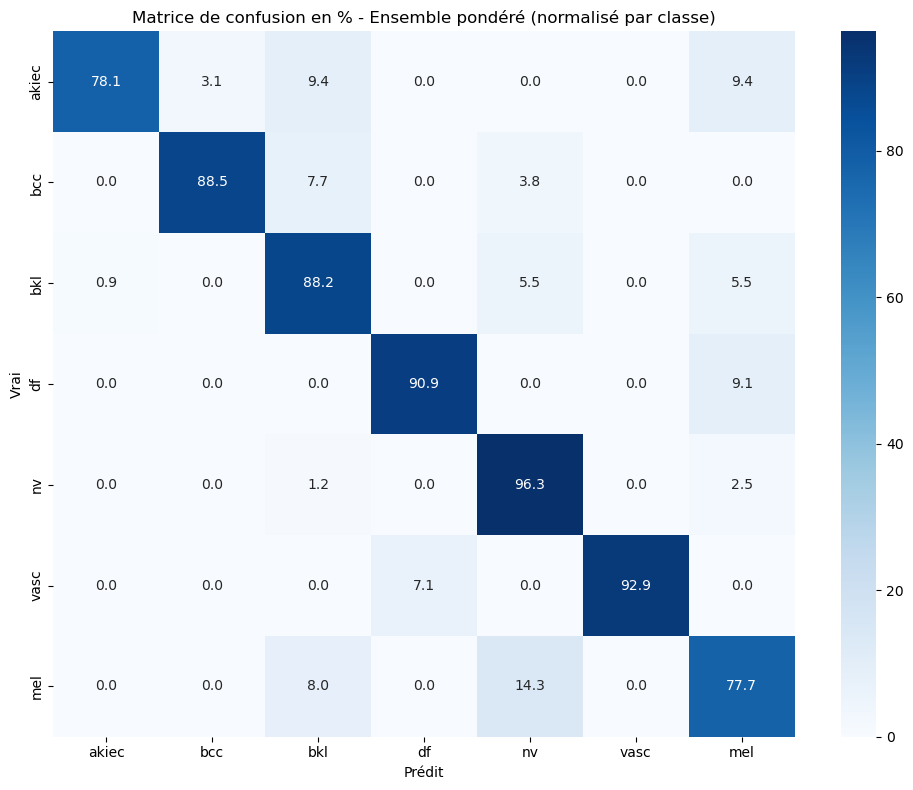


📊 Spécificité par classe:
akiec  : 0.999
bcc    : 0.999
bkl    : 0.973
df     : 0.999
nv     : 0.927
vasc   : 1.000
mel    : 0.970


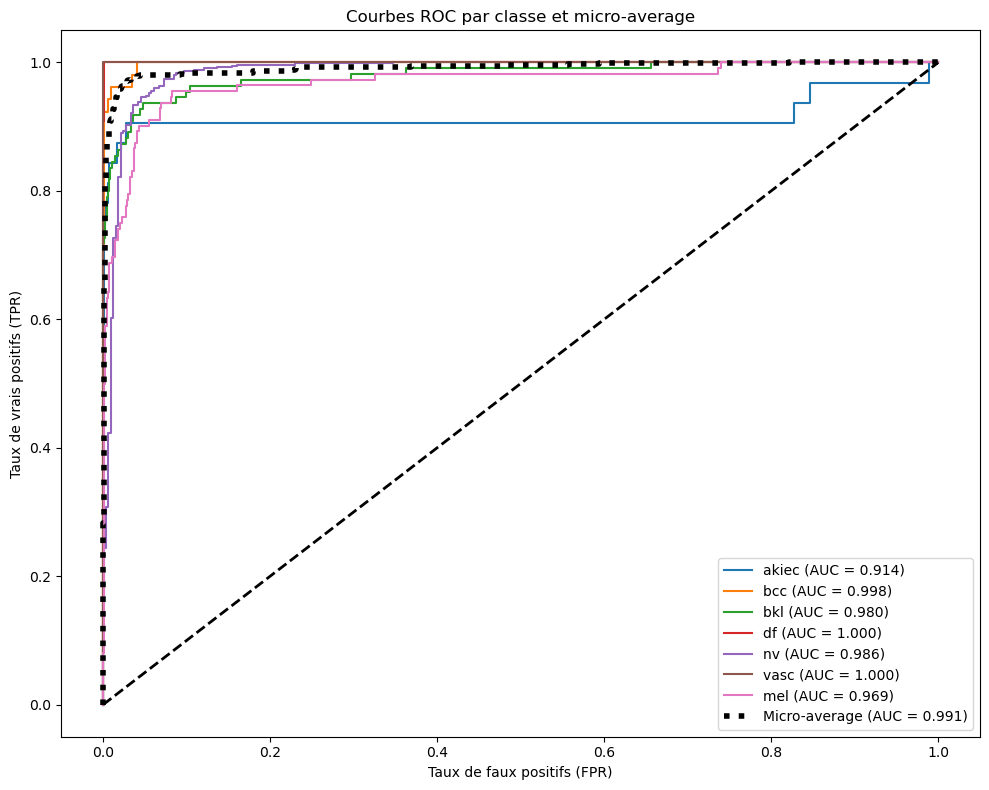


📊 AUC par classe:
akiec  : 0.914
bcc    : 0.998
bkl    : 0.980
df     : 1.000
nv     : 0.986
vasc   : 1.000
mel    : 0.969

Macro AUC : 0.978
Micro AUC : 0.991


In [30]:

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score


# ---- Pondérations des modèles ----
weights_xception = 0.50
weights_resnet   = 0.25
weights_densenet = 0.25

# ---- Fonction pour évaluer avec proba au lieu d'argmax ----
def predict_weighted_ensemble_proba(image_paths, batch_size=32):
    all_preds = []
    num_images = len(image_paths)
    
    for i in tqdm(range(0, num_images, batch_size), desc="Prédiction proba par batchs"):
        batch_paths = image_paths[i:i + batch_size]

        # Charger images
        batch_xcept    = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        batch_resnet   = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))
        batch_densenet = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))

        # Prédictions brutes
        pred_xcept    = model_xcept_big.predict(batch_xcept, verbose=0)
        pred_resnet   = model_resnet50.predict(batch_resnet, verbose=0)
        pred_densenet = model_densenet201.predict(batch_densenet, verbose=0)

        # Appliquer pondérations par classe
        final_pred = (
            pred_xcept * weights_xception +
            pred_resnet * weights_resnet +
            pred_densenet * weights_densenet
        )

        all_preds.append(final_pred)
    
    return np.vstack(all_preds)

# ---- Évaluation avec proba ----
y_true = test_df['label'].values
y_pred_proba = predict_weighted_ensemble_proba(test_df['path'].tolist())
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ---- Matrice de confusion ----
conf_matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion en % - Ensemble pondéré (normalisé par classe)')
plt.tight_layout()
plt.show()

# ---- Spécificité par classe ----
specificities = {}
for i, cls in enumerate(CLASS_NAMES):
    tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
    fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificities[cls] = specificity

print("\n📊 Spécificité par classe:")
for cls, spec in specificities.items():
    print(f"{cls:6s} : {spec:.3f}")

# ---- ROC / AUC ----
y_true_bin = tf.keras.utils.to_categorical(y_true, num_classes=len(CLASS_NAMES))

roc_auc = {}
fpr = {}
tpr = {}

plt.figure(figsize=(10, 8))

for i, cls in enumerate(CLASS_NAMES):
    try:
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        roc_auc[cls] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], label=f"{cls} (AUC = {roc_auc[cls]:.3f})")
    except ValueError:
        roc_auc[cls] = np.nan  # si classe absente

# Macro & micro AUC
macro_auc = roc_auc_score(y_true_bin, y_pred_proba, average="macro", multi_class="ovr")
micro_auc = roc_auc_score(y_true_bin, y_pred_proba, average="micro", multi_class="ovr")

# Courbe ROC micro-avg
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_pred_proba.ravel())
plt.plot(fpr_micro, tpr_micro,
         label=f"Micro-average (AUC = {micro_auc:.3f})", 
         linestyle=":", linewidth=4, color="black")

# Diagonale aléatoire
plt.plot([0, 1], [0, 1], "k--", lw=2)

plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbes ROC par classe et micro-average")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("\n📊 AUC par classe:")
for cls, auc_val in roc_auc.items():
    print(f"{cls:6s} : {auc_val:.3f}")

print(f"\nMacro AUC : {macro_auc:.3f}")
print(f"Micro AUC : {micro_auc:.3f}")


Prédiction par batchs: 100%|██████████| 32/32 [00:30<00:00,  1.05it/s]


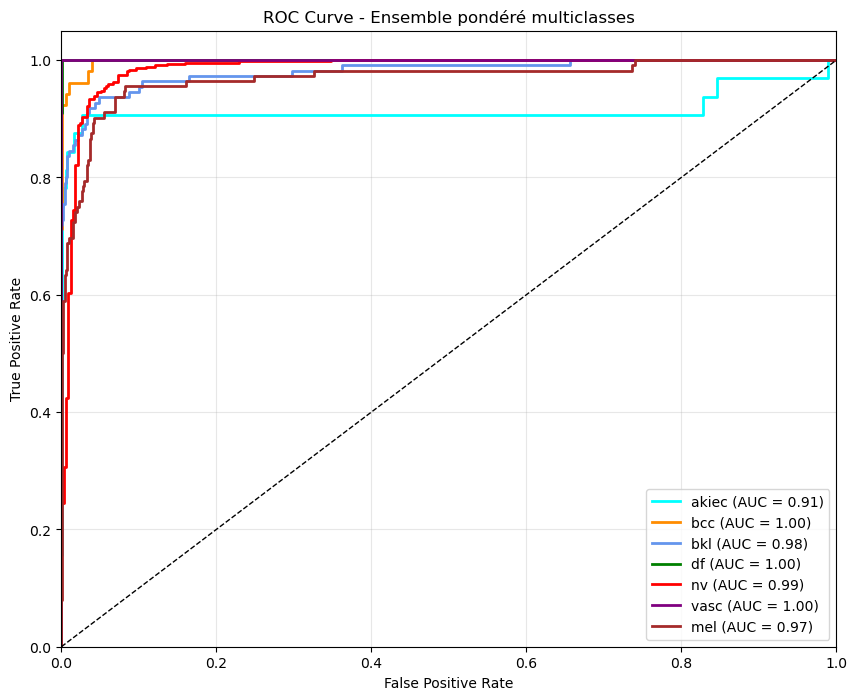

In [31]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Probabilités finales
y_scores = predict_weighted_ensemble_probs(test_df['path'].tolist())
y_true_bin = label_binarize(y_true, classes=np.arange(len(CLASS_NAMES)))  # shape (num_images, 7)

# Calcul FPR, TPR et AUC pour chaque classe
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(CLASS_NAMES)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Tracer
plt.figure(figsize=(10,8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown'])
for i, color in zip(range(len(CLASS_NAMES)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Ensemble pondéré multiclasses')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


In [32]:
optimal_thresholds = {}
for i in range(len(CLASS_NAMES)):
    thresholds = np.linspace(0, 1, 100)
    f1_scores = []
    for t in thresholds:
        y_pred_class = (y_scores[:, i] >= t).astype(int)
        tp = np.sum((y_true_bin[:, i] == 1) & (y_pred_class == 1))
        fp = np.sum((y_true_bin[:, i] == 0) & (y_pred_class == 1))
        fn = np.sum((y_true_bin[:, i] == 1) & (y_pred_class == 0))
        f1 = 2*tp / (2*tp + fp + fn + 1e-8)
        f1_scores.append(f1)
    optimal_thresholds[CLASS_NAMES[i]] = thresholds[np.argmax(f1_scores)]

print("✅ Seuils optimaux par classe :")
for cls, t in optimal_thresholds.items():
    print(f"{cls:6s} → {t:.3f}")


✅ Seuils optimaux par classe :
akiec  → 0.263
bcc    → 0.404
bkl    → 0.515
df     → 0.101
nv     → 0.374
vasc   → 0.354
mel    → 0.303


In [33]:
# ---- Spécificité globale ----
macro_specificity = np.mean(list(specificities.values()))

# Micro = somme TN / (TN + FP) global
TN_total, FP_total = 0, 0
for i in range(len(CLASS_NAMES)):
    tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
    fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
    TN_total += tn
    FP_total += fp
micro_specificity = TN_total / (TN_total + FP_total)

print(f"\n📊 Spécificité globale (macro) : {macro_specificity:.3f}")
print(f"📊 Spécificité globale (micro) : {micro_specificity:.3f}")



📊 Spécificité globale (macro) : 0.981
📊 Spécificité globale (micro) : 0.987


In [34]:
from sklearn.metrics import roc_auc_score, confusion_matrix

# ---- Fonction de calcul des métriques ISIC 2018 ----
def compute_official_metrics(y_true, y_pred, y_prob, class_names):
    n_classes = len(class_names)
    mel_idx = class_names.index('mel')
    conf = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))

    metrics = {}

    # 1) Balanced Multiclass Accuracy = Macro-average recall
    recalls = np.diag(conf) / conf.sum(axis=1, where=conf.sum(axis=1)!=0)
    metrics["BCMA"] = np.nanmean(recalls)

    # 2) Sensitivity for Melanoma
    TP = conf[mel_idx, mel_idx]
    FN = conf[mel_idx, :].sum() - TP
    metrics["Sens_mel"] = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    # 3) Average AUC (one-vs-rest)
    aucs = []
    for c in range(n_classes):
        if np.sum(y_true == c) > 0:  # skip empty classes
            y_true_bin = (y_true == c).astype(int)
            aucs.append(roc_auc_score(y_true_bin, y_prob[:, c]))
    metrics["Avg_AUC"] = np.mean(aucs)

    # 4) Average Specificity
    specs = []
    for c in range(n_classes):
        TN = conf.sum() - (conf[c, :].sum() + conf[:, c].sum() - conf[c, c])
        FP = conf[:, c].sum() - conf[c, c]
        specs.append(TN / (TN + FP) if (TN + FP) > 0 else np.nan)
    metrics["Avg_Spec"] = np.nanmean(specs)

    return metrics

# ---- On modifie la fonction d’ensemble pour renvoyer AUSSI les probabilités ----
def predict_weighted_ensemble(image_paths, batch_size=32):
    all_preds = []
    all_probs = []
    num_images = len(image_paths)
   
    for i in tqdm(range(0, num_images, batch_size), desc="Prédiction par batchs"):
        batch_paths = image_paths[i:i + batch_size]

        # Charger images pour chaque modèle
        batch_xcept      = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        batch_resnet     = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))
        batch_densenet   = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))

        # Prédictions brutes
        pred_xcept    = model_xcept_big.predict(batch_xcept, verbose=0)
        pred_resnet   = model_resnet50.predict(batch_resnet, verbose=0)
        pred_densenet = model_densenet201.predict(batch_densenet, verbose=0)

        # Appliquer pondération classe par classe
        final_pred = (
            pred_xcept * weights_xception +
            pred_resnet * weights_resnet +
            pred_densenet * weights_densenet
        )

        all_probs.append(final_pred)
        all_preds.extend(np.argmax(final_pred, axis=1))
   
    return np.array(all_preds), np.vstack(all_probs)

# ---- Évaluation ----
print("\n📊 Évaluation du modèle d'ensemble pondéré sur le test set...")
y_true = test_df['label'].values
y_pred, y_prob = predict_weighted_ensemble(test_df['path'].tolist())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ---- Métriques officielles ISIC 2018 ----
results = compute_official_metrics(y_true, y_pred, y_prob, CLASS_NAMES)
print("\n📊 Résultats style ISIC 2018 :")
for k, v in results.items():
    print(f"{k:12s} = {v:.3f}")


📊 Évaluation du modèle d'ensemble pondéré sur le test set...


Prédiction par batchs: 100%|██████████| 32/32 [00:30<00:00,  1.05it/s]


Classification Report:
              precision    recall  f1-score   support

       akiec       0.96      0.78      0.86        32
         bcc       0.98      0.88      0.93        52
         bkl       0.80      0.88      0.84       110
          df       0.91      0.91      0.91        11
          nv       0.96      0.96      0.96       671
        vasc       1.00      0.93      0.96        14
         mel       0.76      0.78      0.77       112

    accuracy                           0.92      1002
   macro avg       0.91      0.87      0.89      1002
weighted avg       0.92      0.92      0.92      1002


📊 Résultats style ISIC 2018 :
BCMA         = 0.875
Sens_mel     = 0.777
Avg_AUC      = 0.978
Avg_Spec     = 0.981


# 4️⃣ - Évaluation avec le Benchmarch de ISIC 2018


📊 Évaluation de l'ensemble pondéré (Xception + ResNet50 + DenseNet201)...


Prédiction par batchs: 100%|██████████| 32/32 [00:30<00:00,  1.07it/s]


Classification Report:
              precision    recall  f1-score   support

       akiec       0.96      0.78      0.86        32
         bcc       0.98      0.92      0.95        52
         bkl       0.83      0.87      0.85       110
          df       0.91      0.91      0.91        11
          nv       0.97      0.96      0.97       671
        vasc       1.00      0.93      0.96        14
         mel       0.77      0.84      0.80       112

    accuracy                           0.93      1002
   macro avg       0.92      0.89      0.90      1002
weighted avg       0.93      0.93      0.93      1002



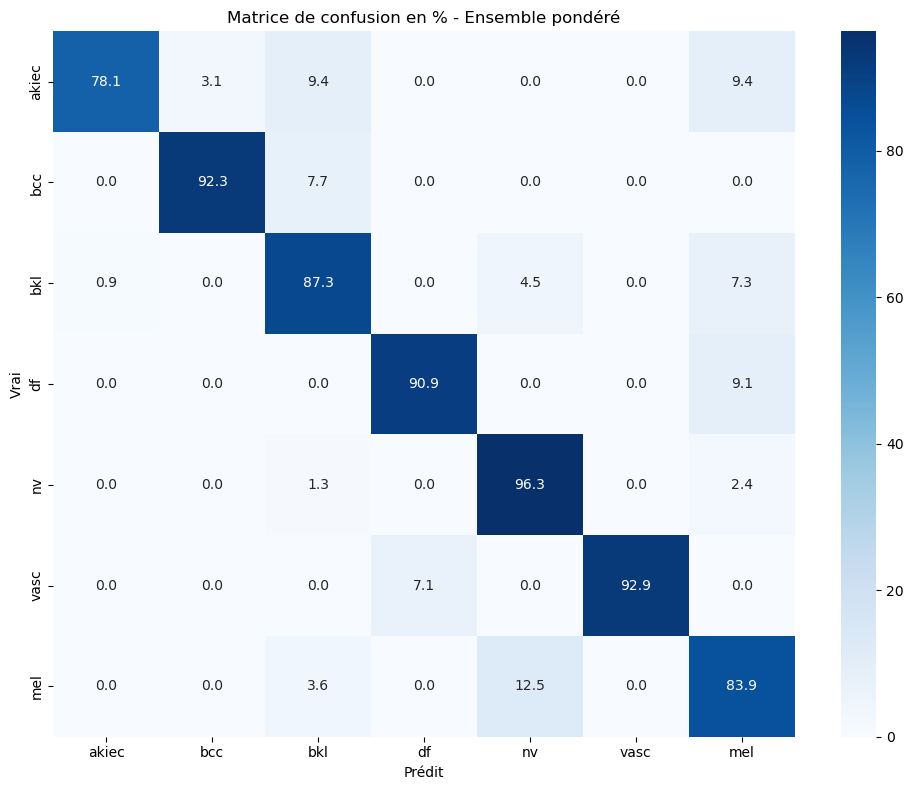


📊 Résultats style ISIC 2018 :
BCMA         = 0.888
Sens_mel     = 0.839
Avg_AUC      = 0.990
Avg_Spec     = 0.984


In [35]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from tqdm import tqdm

# ---- Prédiction en batch avec priorisation DenseNet201 sur 'mel' ----
def predict_ensemble_proba(image_paths, batch_size=32, weights=(0.50, 0.25, 0.25)):
    """
    Retourne les probabilités de prédiction pour chaque classe.
    weights = (w_xception, w_resnet50, w_densenet201)
    """
    num_images = len(image_paths)
    all_probs = []
    for i in tqdm(range(0, num_images, batch_size), desc="Prédiction par batchs"):
        batch_paths = image_paths[i:i + batch_size]
        # Chargement images adaptées
        bx = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        br = preprocess_resnet(load_image_paths(batch_paths, (224, 224)))
        bd = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))
        # Prédictions
        pred_x = model_xcept.predict(bx, verbose=0)
        pred_r = model_resnet50.predict(br, verbose=0)
        pred_d = model_densenet.predict(bd, verbose=0)
        # Moyenne pondérée
        preds = (weights[0] * pred_x +
                 weights[1] * pred_r +
                 weights[2] * pred_d)
        # ASTUCE : privilégier DenseNet201 pour 'mel' (classe index 6)
        mel_idx = label_to_index['mel']
        preds[:, mel_idx] = (0.5 * preds[:, mel_idx] + 0.5 * pred_d[:, mel_idx])
        all_probs.extend(preds)
    return np.array(all_probs)

# ---- Évaluation ----
print("\n📊 Évaluation de l'ensemble pondéré (Xception + ResNet50 + DenseNet201)...")
y_true = test_df['label'].values
y_probs = predict_ensemble_proba(test_df['path'].tolist())
y_pred = np.argmax(y_probs, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred,
                            target_names=CLASS_NAMES,
                            labels=np.arange(len(CLASS_NAMES))))

# Matrice de confusion en %
conf_matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion en % - Ensemble pondéré')
plt.tight_layout()
plt.show()

# ---- Métriques style ISIC 2018 ----
n_classes = len(CLASS_NAMES)
mel_idx = CLASS_NAMES.index('mel')

metrics = {}

# 1) Balanced Multiclass Accuracy (macro recall)
recalls = np.diag(conf_matrix) / np.maximum(conf_matrix.sum(axis=1), 1)  # éviter /0
metrics["BCMA"] = np.nanmean(recalls)

# 2) Sensibilité spécifique melanoma
TP = conf_matrix[mel_idx, mel_idx]
FN = conf_matrix[mel_idx, :].sum() - TP
metrics["Sens_mel"] = TP / (TP + FN) if (TP + FN) > 0 else 0.0

# 3) Average AUC (skip empty classes)
aucs = []
for c in range(n_classes):
    if np.sum(y_true == c) > 0:  # ne calcule que si classe présente
        y_true_bin = (y_true == c).astype(int)
        aucs.append(roc_auc_score(y_true_bin, y_probs[:, c]))
metrics["Avg_AUC"] = np.mean(aucs)

# 4) Average Specificity (formule correcte one-vs-rest)
specs = []
for c in range(n_classes):
    TN = conf_matrix.sum() - (conf_matrix[c, :].sum() + conf_matrix[:, c].sum() - conf_matrix[c, c])
    FP = conf_matrix[:, c].sum() - conf_matrix[c, c]
    specs.append(TN / (TN + FP) if (TN + FP) > 0 else np.nan)
metrics["Avg_Spec"] = np.nanmean(specs)

# ---- Affichage ----
print("\n📊 Résultats style ISIC 2018 :")
for k, v in metrics.items():
    print(f"{k:12s} = {v:.3f}")
